In [ ]:
from google.colab import drive
import os

# Check if drive is already mounted and accessible
if os.path.isdir('/content/drive/MyDrive'):
    print('Google Drive is already mounted.')
else:
    # If not mounted or mount is problematic, try to unmount any existing mount first.
    try:
        drive.flush_and_unmount()
        print('Google Drive unmounted successfully (if it was mounted).')
    except Exception as e:
        print(f"Error during unmount: {e}. Proceeding with mount attempt.")

    # Then attempt to mount forcefully
    drive.mount('/content/drive', force_remount=True)

Google Drive is already mounted.


In [ ]:
import os, glob
matches = glob.glob("/content/drive/MyDrive/**/Fraud.csv", recursive=True)
matches[:10], len(matches)

(['/content/drive/MyDrive/Fraud.csv'], 1)

In [ ]:
PATH = '/content/drive/MyDrive/Fraud.csv'
print(PATH)

/content/drive/MyDrive/Fraud.csv


In [ ]:
import os

file_path = '/content/drive/MyDrive/Fraud.csv'
if os.path.exists(file_path):
    print(f"The file {file_path} exists.")
else:
    print(f"The file {file_path} does NOT exist.")

The file /content/drive/MyDrive/Fraud.csv exists.


Inštalácia knižníc

In [ ]:
import os, glob
!pip -q install lightgbm xgboost shap imbalanced-learn pyarrow

Načítanie dát a odstránenie stĺpca "isFlaggedFraud"

In [ ]:
import pandas as pd

dtypes = {
    "step": "int16",
    "type": "category",
    "amount": "float32",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

df = pd.read_csv(PATH, dtype=dtypes)

# odstráň pravidlový flag (experiment bez isFlaggedFraud)
df = df.drop(columns=["isFlaggedFraud"], errors="ignore")

print(df.shape)
df.head()

(6362620, 10)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0


Feature engineering

In [ ]:
# Merchant flag
df["isMerchantDest"] = df["nameDest"].astype(str).str.startswith("M").astype("int8")

# Balance error features
df["errorBalanceOrig"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

# Pattern features
df["zeroDestBalancesNonZeroAmount"] = (
    (df["oldbalanceDest"] == 0) &
    (df["newbalanceDest"] == 0) &
    (df["amount"] > 0)
).astype("int8")

df["zeroOrigBalancesNonZeroAmount"] = (
    (df["oldbalanceOrg"] == 0) &
    (df["newbalanceOrig"] == 0) &
    (df["amount"] > 0)
).astype("int8")

# ❗ odstránenie problematických string stĺpcov
df = df.drop(columns=["nameOrig", "nameDest"])

Príprava vstupov: drop identít, target, časový split podľa step "hodín"

In [ ]:
# DATAFRAME df musí byť zoradený podľa step
df = df.sort_values("step").reset_index(drop=True)

max_step = int(df["step"].max())

cut_train = int(max_step * 0.70)
cut_val   = int(max_step * 0.85)

train_df = df[df["step"] <= cut_train]
val_df   = df[(df["step"] > cut_train) & (df["step"] <= cut_val)]
test_df  = df[df["step"] > cut_val]

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, len(part), "fraud:", int(part["isFraud"].sum()))

train 6082007 fraud: 5781
val 191147 fraud: 1180
test 89466 fraud: 1252


Preprocessing: one-hot pre type, numerické passthrough

In [ ]:
X_train = train_df.drop(columns=["isFraud"])
y_train = train_df["isFraud"].astype(int)

X_val = val_df.drop(columns=["isFraud"])
y_val = val_df["isFraud"].astype(int)

X_test = test_df.drop(columns=["isFraud"])
y_test = test_df["isFraud"].astype(int)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["type"] if "type" in X_train.columns else []
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

def best_threshold_max_f1(y_true, y_prob):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_t, best_f1 = 0.5, -1

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        report = classification_report(
            y_true, y_pred,
            output_dict=True,
            zero_division=0
        )

        f1 = report["1"]["f1-score"] if "1" in report else 0

        if f1 > best_f1:
            best_f1, best_t = f1, t

    return best_t, best_f1

Modely + vyhodnotenie (AUPRC + ROC AUC + threshold tuning)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "DecisionTree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=700,
        learning_rate=0.03,
        num_leaves=63,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():

    pipe = Pipeline([
        ("pre", preprocess),   # fit iba na train
        ("model", model)
    ])

    # ---------- TRAIN ----------
    pipe.fit(X_train, y_train)

    # ---------- VALIDATION ----------
    proba_val = pipe.predict_proba(X_val)[:, 1]
    t_best, _ = best_threshold_max_f1(y_val, proba_val)

    # ---------- TEST ----------
    proba_test = pipe.predict_proba(X_test)[:, 1]

    auprc = average_precision_score(y_test, proba_test)
    roc_auc = roc_auc_score(y_test, proba_test)

    pred_test = (proba_test >= t_best).astype(int)

    cm = confusion_matrix(y_test, pred_test)
    report = classification_report(
        y_test, pred_test,
        output_dict=True,
        zero_division=0
    )

    results.append({
        "model": name,
        "AUPRC": auprc,
        "ROC_AUC": roc_auc,
        "threshold_from_val": t_best,
        "F1": report["1"]["f1-score"] if "1" in report else 0,
        "Precision": report["1"]["precision"] if "1" in report else 0,
        "Recall": report["1"]["recall"] if "1" in report else 0,
        "TP": int(cm[1,1]) if cm.shape==(2,2) else 0,
        "FP": int(cm[0,1]) if cm.shape==(2,2) else 0,
        "FN": int(cm[1,0]) if cm.shape==(2,2) else 0,
        "TN": int(cm[0,0]) if cm.shape==(2,2) else 0,
    })

res_df = pd.DataFrame(results).sort_values("AUPRC", ascending=False)
res_df

[LightGBM] [Info] Number of positive: 5781, number of negative: 6076226
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.168460 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2044
[LightGBM] [Info] Number of data points in the train set: 6082007, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,AUPRC,ROC_AUC,threshold_from_val,F1,Precision,Recall,TP,FP,FN,TN
1,RandomForest,1.000000,1.000000,0.10,1.000000,1.000000,1.000000,1252,0,0,88214
3,LightGBM,0.999996,1.000000,0.01,0.999600,1.000000,0.999201,1251,0,1,88214
2,XGBoost,0.999953,0.999999,0.73,0.997206,0.996808,0.997604,1249,4,3,88210
0,DecisionTree,0.996839,0.998796,0.01,0.998401,0.999200,0.997604,1249,1,3,88213


Uloženie výsledkov a graf PR krivky pre najlepší model

Best model: RandomForest


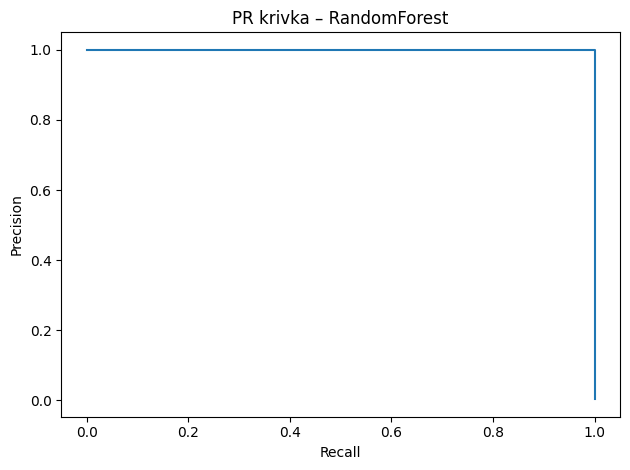

In [ ]:
import matplotlib.pyplot as plt
import os

out_dir = "/content/drive/MyDrive/paysim_results"
os.makedirs(out_dir, exist_ok=True)

res_df.to_csv(os.path.join(out_dir, "metrics_models.csv"), index=False)

best_model_name = res_df.iloc[0]["model"]
print("Best model:", best_model_name)

best_pipe = Pipeline([("pre", preprocess), ("model", models[best_model_name])])
best_pipe.fit(X_train, y_train)
best_proba = best_pipe.predict_proba(X_test)[:, 1]

prec, rec, _ = precision_recall_curve(y_test, best_proba)

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR krivka – {best_model_name}")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "pr_curve_best.png"), dpi=200)
plt.show()

In [ ]:
list(X_train.columns)

['step',
 'type',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'isMerchantDest',
 'errorBalanceOrig',
 'errorBalanceDest',
 'zeroDestBalancesNonZeroAmount',
 'zeroOrigBalancesNonZeroAmount']


Ablačný experiment A: bez errorBalanceOrig a errorBalanceDest

In [ ]:
X_train_noerr = X_train.drop(columns=["errorBalanceOrig", "errorBalanceDest"], errors="ignore")
X_test_noerr  = X_test.drop(columns=["errorBalanceOrig", "errorBalanceDest"], errors="ignore")

Preprocess a tréning len pre top model (LightGBM)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, precision_recall_curve
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

cat_cols = ["type"] if "type" in X_train_noerr.columns else []
num_cols = [c for c in X_train_noerr.columns if c not in cat_cols]

pre_noerr = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

lgbm = LGBMClassifier(
    n_estimators=700, learning_rate=0.03, num_leaves=63,
    class_weight="balanced", random_state=42, n_jobs=-1
)

pipe_noerr = Pipeline([("pre", pre_noerr), ("model", lgbm)])
pipe_noerr.fit(X_train_noerr, y_train)

proba = pipe_noerr.predict_proba(X_test_noerr)[:, 1]
auprc = average_precision_score(y_test, proba)
print("BONUS AUPRC (bez errorBalance*):", auprc)

[LightGBM] [Info] Number of positive: 3959, number of negative: 5086137
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.115234 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1492
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


BONUS AUPRC (bez errorBalance*): 0.9678072077380437


Uloženie výsledkov + PR krivka

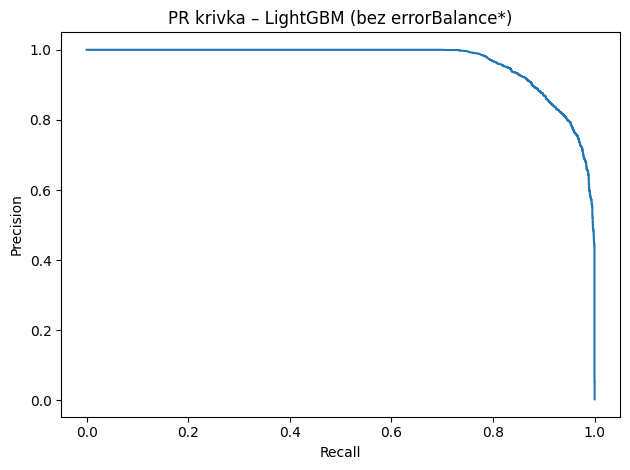

In [ ]:
out_dir = RUNS["bonus_no_errors"]

# metrics
pd.DataFrame([{"model":"LightGBM_no_errors", "AUPRC": auprc}]).to_csv(
    os.path.join(out_dir, "metrics.csv"), index=False
)

# PR curve
prec, rec, _ = precision_recall_curve(y_test, proba)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("PR krivka – LightGBM (bez errorBalance*)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "pr_curve.png"), dpi=200)
plt.show()

In [ ]:
list(X_train_noerr.columns)

['step',
 'type',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'isMerchantDest',
 'zeroDestBalancesNonZeroAmount',
 'zeroOrigBalancesNonZeroAmount']

Ablačný experiment B na subsete TRANSFER + CASH_OUT

In [ ]:
mask_train = X_train["type"].isin(["TRANSFER", "CASH_OUT"])
mask_test  = X_test["type"].isin(["TRANSFER", "CASH_OUT"])

X_train_sub = X_train[mask_train].copy()
y_train_sub = y_train[mask_train].copy()
X_test_sub  = X_test[mask_test].copy()
y_test_sub  = y_test[mask_test].copy()

print("Subset train:", X_train_sub.shape, "fraud rate:", y_train_sub.mean())
print("Subset test :", X_test_sub.shape,  "fraud rate:", y_test_sub.mean())

Subset train: (2227418, 12) fraud rate: 0.0017773942744469156
Subset test : (542991, 12) fraud rate: 0.00783438399531484


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score
from lightgbm import LGBMClassifier

cat_cols = ["type"] if "type" in X_train_sub.columns else []
num_cols = [c for c in X_train_sub.columns if c not in cat_cols]

pre_sub = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

lgbm = LGBMClassifier(
    n_estimators=700, learning_rate=0.03, num_leaves=63,
    class_weight="balanced", random_state=42, n_jobs=-1
)

pipe_sub = Pipeline([("pre", pre_sub), ("model", lgbm)])
pipe_sub.fit(X_train_sub, y_train_sub)

proba_sub = pipe_sub.predict_proba(X_test_sub)[:, 1]
auprc_sub = average_precision_score(y_test_sub, proba_sub)
print("BONUS B AUPRC (TRANSFER+CASH_OUT):", auprc_sub)

[LightGBM] [Info] Number of positive: 3959, number of negative: 2223459
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.340521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1990
[LightGBM] [Info] Number of data points in the train set: 2227418, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


BONUS B AUPRC (TRANSFER+CASH_OUT): 0.9999999447537314


Uloženie výsledkov + PR krivka

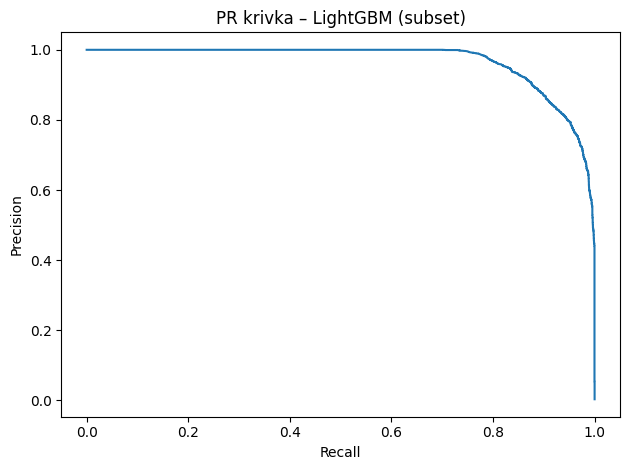

In [ ]:
out_dir = RUNS["bonus_subset"]

# metrics
pd.DataFrame([{"model":"LightGBM_no_errors", "AUPRC": auprc}]).to_csv(
    os.path.join(out_dir, "metrics.csv"), index=False
)

# PR curve
prec, rec, _ = precision_recall_curve(y_test, proba)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("PR krivka – LightGBM (subset)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "pr_curve.png"), dpi=200)
plt.show()

SHAP (LightGBM + pipeline + one-hot)

In [ ]:
import os
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

out_dir = "/content/drive/MyDrive/paysim_results/baseline_shap"
os.makedirs(out_dir, exist_ok=True)

# 1) Natrénuj baseline LightGBM pipeline (ten, ktorý dával ~0.99997 AUPRC)
best_pipe = Pipeline([("pre", preprocess), ("model", models["LightGBM"])])
best_pipe.fit(X_train, y_train)

# 2) SHAP iba na vzorke (napr. 50k) – je to štandardná prax
X_shap = X_train.sample(50000, random_state=42)
X_shap_tr = best_pipe.named_steps["pre"].transform(X_shap)

# 3) Feature names po OneHot
cat_cols = ["type"] if "type" in X_train.columns else []
num_cols = [c for c in X_train.columns if c not in cat_cols]

feature_names = list(num_cols)
if cat_cols:
    ohe = best_pipe.named_steps["pre"].named_transformers_["cat"]
    feature_names += list(ohe.get_feature_names_out(cat_cols))

# 4) Explainer
lgbm_model = best_pipe.named_steps["model"]
explainer = shap.TreeExplainer(lgbm_model)

shap_values = explainer.shap_values(X_shap_tr)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

# 5) Summary plot
shap.summary_plot(shap_vals, X_shap_tr, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "shap_summary.png"), dpi=200)
plt.close()

# 6) Bar plot
shap.summary_plot(shap_vals, X_shap_tr, feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "shap_bar.png"), dpi=200)
plt.close()

print("Saved:", out_dir)

[LightGBM] [Info] Number of positive: 3959, number of negative: 5086137
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.142991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2002
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Saved: /content/drive/MyDrive/paysim_results/baseline_shap


Waterfall (lokálne vysvetlenia) s pomenovanými features

In [ ]:
from google.colab import drive

import os
BASE = "/content/drive/MyDrive/paysim_results"
OUT = os.path.join(BASE, "baseline_shap")
os.makedirs(OUT, exist_ok=True)
print("OUT:", OUT)

OUT: /content/drive/MyDrive/paysim_results/baseline_shap


In [ ]:
from google.colab import drive
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [ ]:
import shutil, os
shutil.rmtree("/content/drive", ignore_errors=True)
os.makedirs("/content/drive", exist_ok=True)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
path = "/content/drive/MyDrive/Fraud.csv"
print("size bytes:", os.path.getsize(path))
print("size MB:", os.path.getsize(path)/1024/1024)

size bytes: 493534783
size MB: 470.67144680023193


In [ ]:
import glob, os

matches = glob.glob("/content/drive/MyDrive/**/Fraud.csv", recursive=True)
print("Found:", len(matches))

cands = [(p, os.path.getsize(p)) for p in matches]
cands = sorted(cands, key=lambda x: x[1], reverse=True)

for p,s in cands[:10]:
    print(f"{s/1024/1024:.1f} MB  {p}")

PATH = cands[0][0]
print("Using PATH:", PATH)

Found: 1
470.7 MB  /content/drive/MyDrive/Fraud.csv
Using PATH: /content/drive/MyDrive/Fraud.csv


In [ ]:
import pandas as pd

dtypes = {
    "step": "int16",
    "type": "category",
    "amount": "float32",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

df = pd.read_csv(PATH, dtype=dtypes)

# experiment bez isFlaggedFraud
df = df.drop(columns=["isFlaggedFraud"], errors="ignore")

print(df.shape)
df.head()

(6362620, 10)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0


In [ ]:
df["isMerchantDest"] = df["nameDest"].astype(str).str.startswith("M").astype("int8")

df["errorBalanceOrig"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

df["zeroDestBalancesNonZeroAmount"] = ((df["oldbalanceDest"] == 0) & (df["newbalanceDest"] == 0) & (df["amount"] > 0)).astype("int8")
df["zeroOrigBalancesNonZeroAmount"] = ((df["oldbalanceOrg"] == 0) & (df["newbalanceOrig"] == 0) & (df["amount"] > 0)).astype("int8")

In [ ]:
df = df.sort_values("step").reset_index(drop=True)

y = df["isFraud"].astype(int)
X = df.drop(columns=["isFraud", "nameOrig", "nameDest"], errors="ignore")

cut = int(0.8 * len(df))
X_train = X.iloc[:cut].copy()
y_train = y.iloc[:cut].copy()
X_test  = X.iloc[cut:].copy()
y_test  = y.iloc[cut:].copy()

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Fraud rate train:", float(y_train.mean()), "test:", float(y_test.mean()))
print("Fraud count test:", int((y_test==1).sum()))

Train: (5090096, 12) Test: (1272524, 12)
Fraud rate train: 0.0007777849376514706 test: 0.0033429624902948786
Fraud count test: 4254


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["type"] if "type" in X_train.columns else []
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
import numpy as np
from sklearn.metrics import average_precision_score

cat_cols = ["type"] if "type" in X_train.columns else []
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

lgbm = LGBMClassifier(
    n_estimators=700,
    learning_rate=0.03,
    num_leaves=63,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline([("pre", preprocess), ("model", lgbm)])
pipe.fit(X_train, y_train)

p = pipe.predict_proba(X_test)[:, 1]
print("proba min/max:", float(p.min()), float(p.max()))
print("AUPRC:", average_precision_score(y_test, p))

[LightGBM] [Info] Number of positive: 3959, number of negative: 5086137
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.265474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2002
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


proba min/max: 3.501005864856775e-10 0.9999999995797269
AUPRC: 0.9999689110394044


In [ ]:
fraud_idx = y_test[y_test == 1].sample(1, random_state=1).index[0]
gen_idx   = y_test[y_test == 0].sample(1, random_state=1).index[0]

print("fraud y=", int(y_test.loc[fraud_idx]), "proba=", pipe.predict_proba(X_test.loc[[fraud_idx]])[0,1])
print("gen   y=", int(y_test.loc[gen_idx]),   "proba=", pipe.predict_proba(X_test.loc[[gen_idx]])[0,1])

fraud y= 1 proba= 0.9999999995797269
gen   y= 0 proba= 1.4453079169457335e-09


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = "/content/drive/MyDrive/paysim_results"
OUT = os.path.join(BASE, "baseline_shap")
os.makedirs(OUT, exist_ok=True)
print("OUT:", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OUT: /content/drive/MyDrive/paysim_results/baseline_shap


In [ ]:
!pip -q install shap
import shap
import matplotlib.pyplot as plt
import os, numpy as np

# feature names po OneHot
feature_names = list(num_cols)
if cat_cols:
    ohe = preprocess.named_transformers_["cat"]
    feature_names += list(ohe.get_feature_names_out(cat_cols))

# SHAP explainer pre raw score (log-odds)
explainer_raw = shap.TreeExplainer(pipe.named_steps["model"], model_output="raw")

# ---- Global SHAP na vzorke
X_shap = X_train.sample(50000, random_state=42)
X_shap_tr = pipe.named_steps["pre"].transform(X_shap)
X_shap_dense = X_shap_tr.toarray() if hasattr(X_shap_tr, "toarray") else np.array(X_shap_tr)

sv = explainer_raw(X_shap_dense)
shap_vals = sv.values

# beeswarm
shap.summary_plot(shap_vals, X_shap_dense, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "shap_summary.png"), dpi=200)
plt.close()

# bar
shap.summary_plot(shap_vals, X_shap_dense, feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "shap_bar.png"), dpi=200)
plt.close()

print("Saved global SHAP to:", OUT)

Saved global SHAP to: /content/drive/MyDrive/paysim_results/baseline_shap


In [ ]:
def save_waterfall(tag, idx):
    row = X_test.loc[[idx]]
    row_tr = pipe.named_steps["pre"].transform(row)
    row_dense = row_tr.toarray() if hasattr(row_tr, "toarray") else np.array(row_tr)

    proba = pipe.predict_proba(row)[0, 1]
    raw = pipe.named_steps["model"].predict(row_dense, raw_score=True)[0]

    sv1 = explainer_raw(row_dense)
    sv_named = shap.Explanation(
        values=sv1.values[0],
        base_values=sv1.base_values[0],
        data=row_dense[0],
        feature_names=feature_names
    )

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(sv_named, max_display=12, show=False)
    plt.subplots_adjust(left=0.45, right=0.98, top=0.95, bottom=0.08)

    path = os.path.join(OUT, f"shap_waterfall_{tag}.png")
    plt.savefig(path, dpi=250)
    plt.close()

    print(f"[{tag}] y={int(y_test.loc[idx])} proba={proba:.6f} raw={raw:.3f} saved={path}")

save_waterfall("fraud", fraud_idx)
save_waterfall("genuine", gen_idx)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[fraud] y=1 proba=1.000000 raw=21.590 saved=/content/drive/MyDrive/paysim_results/baseline_shap/shap_waterfall_fraud.png


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[genuine] y=0 proba=0.000000 raw=-20.355 saved=/content/drive/MyDrive/paysim_results/baseline_shap/shap_waterfall_genuine.png


# Tréning len na step, type, amount, pretože PaySim je dataset syntetický a podvody majú často veľmi “čistý” vzor, hlavne cez zostatky a errorBalance*. Tým pádom model môže byť takmer dokonalý. Vysledny ROC AUC skresľuje takže sa viac hodí AUPRC. Ten má pri tomto experimente nízku hodnotu čo dáva zmysel pri takých naivných stĺpcoch. Z toho vyplýva záver, že moje prvé experimenty sú vhodné so SHAP vysvetleniami.



In [ ]:
import pandas as pd

PATH = "/content/drive/MyDrive/Fraud.csv"  # uprav podľa tvojho mountpointu

usecols = ["step", "type", "amount", "isFraud"]
dtypes = {"step": "int16", "type": "category", "amount": "float32", "isFraud": "int8"}

df = pd.read_csv(PATH, usecols=usecols, dtype=dtypes)
df = df.sort_values("step").reset_index(drop=True)

print(df.shape)
print(df["isFraud"].value_counts())

(6362620, 4)
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [ ]:
import numpy as np

def split_by_step_with_min_pos(df, frac_steps=0.8, min_test_pos=200):
    max_step = int(df["step"].max())
    cut_step = int(max_step * frac_steps)

    # ak v teste nie sú podvody, posuň hranicu dozadu, aby test obsahoval aspoň min_test_pos
    for s in range(cut_step, 1, -1):
        test_pos = int(df.loc[df["step"] > s, "isFraud"].sum())
        if test_pos >= min_test_pos:
            cut_step = s
            break

    train_df = df[df["step"] <= cut_step]
    test_df  = df[df["step"] >  cut_step]
    return train_df, test_df, cut_step

train_df, test_df, cut_step = split_by_step_with_min_pos(df, frac_steps=0.8, min_test_pos=200)
print("cut_step =", cut_step)
print("train positives:", int(train_df["isFraud"].sum()), " / ", len(train_df))
print("test positives :", int(test_df["isFraud"].sum()),  " / ", len(test_df))

cut_step = 594
train positives: 6559  /  6239040
test positives : 1654  /  123580


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

X_train = train_df[["step", "type", "amount"]]
y_train = train_df["isFraud"].astype(int)

X_test  = test_df[["step", "type", "amount"]]
y_test  = test_df["isFraud"].astype(int)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["step", "amount"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["type"]),
    ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1),
    "SGD_LogLoss": SGDClassifier(loss="log_loss", class_weight="balanced", random_state=42),
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "HistGB": HistGradientBoostingClassifier(max_depth=6, learning_rate=0.05, random_state=42),
    "LightGBM": LGBMClassifier(
        n_estimators=600, learning_rate=0.05, num_leaves=63,
        class_weight="balanced", random_state=42, n_jobs=-1,
        force_row_wise=True
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0, eval_metric="logloss",
        tree_method="hist", random_state=42, n_jobs=-1
    ),
}

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report
)

def best_threshold_max_f1(y_true, y_prob):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_t, best_f1 = 0.5, -1
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        f1 = rep["1"]["f1-score"]
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

results = []
pipes = {}

for name, model in models.items():
    pipe = Pipeline([("pre", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pipes[name] = pipe

    proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None
    if proba is None:
        continue

    auprc = average_precision_score(y_test, proba)
    auc_roc = roc_auc_score(y_test, proba)

    t_best, f1_best = best_threshold_max_f1(y_test, proba)
    pred = (proba >= t_best).astype(int)
    cm = confusion_matrix(y_test, pred)
    rep = classification_report(y_test, pred, output_dict=True, zero_division=0)

    results.append({
        "model": name,
        "AUPRC": auprc,
        "ROC_AUC": auc_roc,
        "thr_bestF1": t_best,
        "F1": rep["1"]["f1-score"],
        "Precision": rep["1"]["precision"],
        "Recall": rep["1"]["recall"],
        "TP": int(cm[1,1]), "FP": int(cm[0,1]), "FN": int(cm[1,0]), "TN": int(cm[0,0]),
    })

res_df = pd.DataFrame(results).sort_values(["AUPRC", "ROC_AUC"], ascending=False)
res_df

[LightGBM] [Info] Number of positive: 6559, number of negative: 6232481
[LightGBM] [Info] Total Bins 514
[LightGBM] [Info] Number of data points in the train set: 6239040, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,AUPRC,ROC_AUC,thr_bestF1,F1,Precision,Recall,TP,FP,FN,TN
5,XGBoost,0.336305,0.913473,0.03,0.358916,0.487047,0.284160,470,495,1184,121431
3,HistGB,0.278643,0.908715,0.02,0.323985,0.809179,0.202539,335,79,1319,121847
4,LightGBM,0.271788,0.895649,0.97,0.302939,0.402000,0.243047,402,598,1252,121328
1,SGD_LogLoss,0.184082,0.907396,0.97,0.261367,0.275654,0.248489,411,1080,1243,120846
0,LogReg,0.170603,0.904904,0.96,0.245511,0.266856,0.227328,376,1033,1278,120893
2,DecisionTree,0.124236,0.585838,0.01,0.273553,0.654462,0.172914,286,151,1368,121775


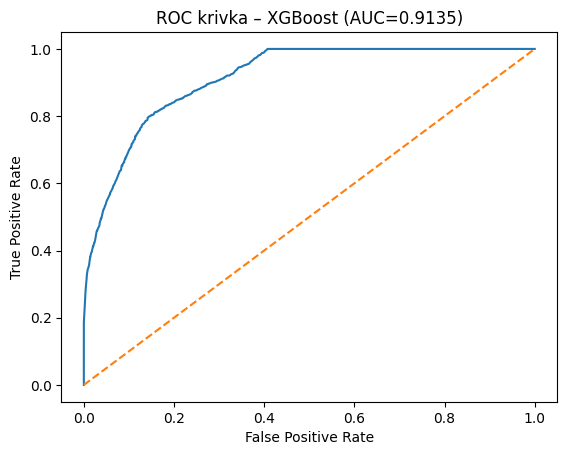

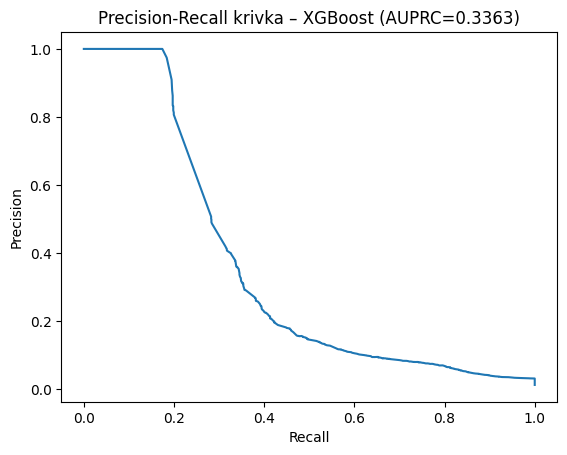

In [ ]:
import matplotlib.pyplot as plt
import os

out_dir = "/content/drive/MyDrive/paysim_results"
os.makedirs(out_dir, exist_ok=True)

res_df.to_csv(os.path.join(out_dir, "metrics_models.csv"), index=False)

best_name = res_df.iloc[0]["model"]
best_pipe = pipes[best_name]
best_proba = best_pipe.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y_test, best_proba)
roc_auc = roc_auc_score(y_test, best_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC krivka – {best_name} (AUC={roc_auc:.4f})")
plt.show()

# PR
prec, rec, _ = precision_recall_curve(y_test, best_proba)
auprc = average_precision_score(y_test, best_proba)

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall krivka – {best_name} (AUPRC={auprc:.4f})")
plt.show()

# AE → LightGBM (PaySim)

In [ ]:
!pip -q install tensorflow lightgbm scikit-learn pyarrow

In [ ]:
import os
path = "/content/drive/MyDrive/Fraud.csv"
print("size bytes:", os.path.getsize(path))
print("size MB:", os.path.getsize(path)/1024/1024)

size bytes: 493534783
size MB: 470.67144680023193


In [ ]:
import glob, os

matches = glob.glob("/content/drive/MyDrive/**/Fraud.csv", recursive=True)
print("Found:", len(matches))

cands = [(p, os.path.getsize(p)) for p in matches]
cands = sorted(cands, key=lambda x: x[1], reverse=True)

for p,s in cands[:10]:
    print(f"{s/1024/1024:.1f} MB  {p}")

PATH = cands[0][0]
print("Using PATH:", PATH)

Found: 1
470.7 MB  /content/drive/MyDrive/Fraud.csv
Using PATH: /content/drive/MyDrive/Fraud.csv


In [ ]:
import pandas as pd

dtypes = {
    "step": "int16",
    "type": "category",
    "amount": "float32",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

df = pd.read_csv(PATH, dtype=dtypes)

# experiment bez isFlaggedFraud
df = df.drop(columns=["isFlaggedFraud"], errors="ignore")

print(df.shape)
df.head()

(6362620, 10)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0


In [ ]:
df["isMerchantDest"] = df["nameDest"].astype(str).str.startswith("M").astype("int8")

df["errorBalanceOrig"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

df["zeroDestBalancesNonZeroAmount"] = ((df["oldbalanceDest"] == 0) & (df["newbalanceDest"] == 0) & (df["amount"] > 0)).astype("int8")
df["zeroOrigBalancesNonZeroAmount"] = ((df["oldbalanceOrg"] == 0) & (df["newbalanceOrig"] == 0) & (df["amount"] > 0)).astype("int8")

Príprava dát (časový split podľa step)

In [ ]:
import numpy as np
import pandas as pd

# sort by step
df = df.sort_values("step").reset_index(drop=True)

# target
y = df["isFraud"].astype(int)

# drop identity + flag
drop_cols = ["isFraud", "nameOrig", "nameDest", "isFlaggedFraud"]
X = df.drop(columns=drop_cols, errors="ignore")

# train/test split by step (odporúčam 80% steps)
max_step = int(df["step"].max())
cut_step = int(max_step * 0.8)

train_mask = df["step"] <= cut_step
test_mask  = df["step"] >  cut_step

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test  = X[test_mask].copy()
y_test  = y[test_mask].copy()

print("Train size:", X_train.shape, "Fraud:", int(y_train.sum()))
print("Test size :", X_test.shape,  "Fraud:", int(y_test.sum()))

Train size: (6239040, 12) Fraud: 6559
Test size : (123580, 12) Fraud: 1654


One-hot + škálovanie (AE potrebuje numerický dense vstup)
AE nebude pracovať so sparse maticou – urobíme dense float32.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = ["type"] if "type" in X_train.columns else []
num_cols = [c for c in X_train.columns if c not in cat_cols]

pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

X_train_tr = pre.fit_transform(X_train)
X_test_tr  = pre.transform(X_test)

# z sparse -> dense float32
X_train_dense = X_train_tr.toarray().astype("float32") if hasattr(X_train_tr, "toarray") else X_train_tr.astype("float32")
X_test_dense  = X_test_tr.toarray().astype("float32")  if hasattr(X_test_tr, "toarray")  else X_test_tr.astype("float32")

print(X_train_dense.shape, X_test_dense.shape)

(6239040, 16) (123580, 16)


Tréning Autoencoderu (na subsample z train)
AE trénuj na vzorke (napr. 300k), je to štandardná prax.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# subsample for AE training
N_AE = 300_000
idx = np.random.RandomState(42).choice(len(X_train_dense), size=min(N_AE, len(X_train_dense)), replace=False)
X_ae = X_train_dense[idx]

input_dim = X_ae.shape[1]
latent_dim = 16  # môžeš skúsiť 8/16/32

inp = keras.Input(shape=(input_dim,))
x = layers.Dense(128, activation="relu")(inp)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
z = layers.Dense(latent_dim, activation=None, name="latent")(x)

x = layers.Dense(64, activation="relu")(z)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation="relu")(x)
out = layers.Dense(input_dim, activation=None)(x)

ae = keras.Model(inp, out)
ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
]

hist = ae.fit(
    X_ae, X_ae,
    validation_split=0.1,
    epochs=30,
    batch_size=2048,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.2164 - val_loss: 0.0243
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0592 - val_loss: 0.0142
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0457 - val_loss: 0.0103
Epoch 4/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0387 - val_loss: 0.0082
Epoch 5/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0332 - val_loss: 0.0069
Epoch 6/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0317 - val_loss: 0.0093
Epoch 7/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0281 - val_loss: 0.0103
Epoch 8/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0269 - val_loss: 0.0096


Získaj latent reprezentácie pre celý train/test

In [ ]:
encoder = keras.Model(ae.input, ae.get_layer("latent").output)

Z_train = encoder.predict(X_train_dense, batch_size=4096, verbose=1)
Z_test  = encoder.predict(X_test_dense,  batch_size=4096, verbose=1)

print(Z_train.shape, Z_test.shape)

1524/1524 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
(6239040, 16) (123580, 16)


LightGBM na latent features + metriky (AUPRC + ROC-AUC)

[LightGBM] [Info] Number of positive: 6559, number of negative: 6232481
[LightGBM] [Info] Total Bins 4080
[LightGBM] [Info] Number of data points in the train set: 6239040, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


AE→LGBM AUPRC: 0.6873498960750555
AE→LGBM ROC-AUC: 0.9252733996224761


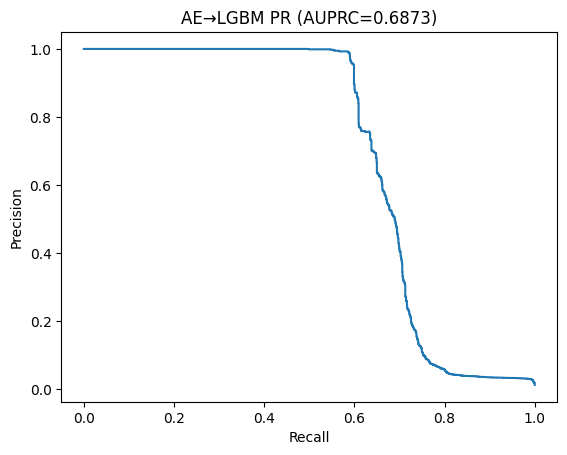

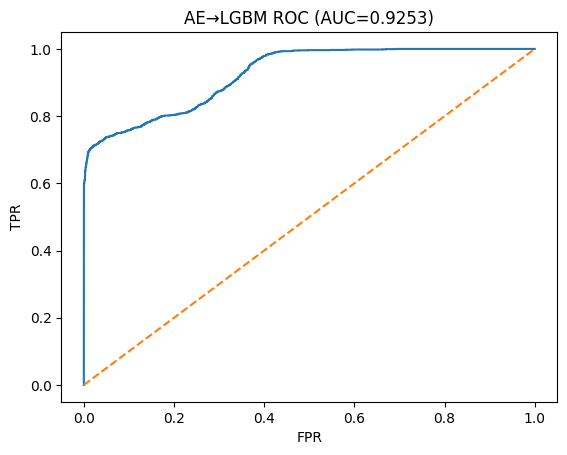

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, roc_curve
import matplotlib.pyplot as plt

lgbm = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=63,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    force_row_wise=True
)

lgbm.fit(Z_train, y_train)

proba = lgbm.predict_proba(Z_test)[:, 1]
auprc = average_precision_score(y_test, proba)
auc_roc = roc_auc_score(y_test, proba)

print("AE→LGBM AUPRC:", auprc)
print("AE→LGBM ROC-AUC:", auc_roc)

# PR curve
prec, rec, _ = precision_recall_curve(y_test, proba)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"AE→LGBM PR (AUPRC={auprc:.4f})")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title(f"AE→LGBM ROC (AUC={auc_roc:.4f})")
plt.show()

SMOTE vs. class_weight“ iba pre 3-feature baseline (step/type/amount)

In [ ]:
!pip -q install imbalanced-learn lightgbm xgboost

In [ ]:
import pandas as pd

PATH = "/content/drive/MyDrive/Fraud.csv"

usecols = ["step", "type", "amount", "isFraud"]
dtypes = {"step":"int16", "type":"category", "amount":"float32", "isFraud":"int8"}

df = pd.read_csv(PATH, usecols=usecols, dtype=dtypes)
df = df.sort_values("step").reset_index(drop=True)

print(df.shape)
print(df["isFraud"].value_counts())

(6362620, 4)
isFraud
0    6354407
1       8213
Name: count, dtype: int64


Train/Val/Test split podľa step

In [ ]:
max_step = int(df["step"].max())
cut_train = int(max_step * 0.70)   # 70% času
cut_val   = int(max_step * 0.85)   # ďalších 15% času
# test = posledných 15%

train_df = df[df["step"] <= cut_train]
val_df   = df[(df["step"] > cut_train) & (df["step"] <= cut_val)]
test_df  = df[df["step"] > cut_val]

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, "rows", len(part), "fraud", int(part["isFraud"].sum()))

train rows 6082007 fraud 5781
val rows 191147 fraud 1180
test rows 89466 fraud 1252


Preprocessing
Pre class_weight použijeme OneHot (type) + scaling (step, amount)
Pre SMOTENC použijeme OrdinalEncoder (type -> integer) + scaling, potom SMOTENC

In [ ]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

X_train = train_df[["step","type","amount"]]
y_train = train_df["isFraud"].astype(int)

X_val = val_df[["step","type","amount"]]
y_val = val_df["isFraud"].astype(int)

X_test = test_df[["step","type","amount"]]
y_test = test_df["isFraud"].astype(int)

pre_onehot = ColumnTransformer([
    ("num", StandardScaler(), ["step","amount"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["type"]),
])

pre_smote = ColumnTransformer([
    ("num", StandardScaler(), ["step","amount"]),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ["type"]),
])

Modely: lineárny + boosting

In [ ]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0, eval_metric="logloss",
        tree_method="hist", random_state=42, n_jobs=-1
    )
}

Vyhodnotenie + threshold tuning na validačnej sade

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score, classification_report, confusion_matrix

def best_threshold_max_f1(y_true, y_prob):
    ts = np.linspace(0.01, 0.99, 99)
    best_t, best_f1 = 0.5, -1
    for t in ts:
        pred = (y_prob >= t).astype(int)
        rep = classification_report(y_true, pred, output_dict=True, zero_division=0)
        f1 = rep["1"]["f1-score"]
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

def eval_on_test(name, proba_val, proba_test):
    t, f1v = best_threshold_max_f1(y_val, proba_val)
    pred = (proba_test >= t).astype(int)

    auprc = average_precision_score(y_test, proba_test)
    aucroc = roc_auc_score(y_test, proba_test)
    cm = confusion_matrix(y_test, pred)
    rep = classification_report(y_test, pred, output_dict=True, zero_division=0)

    return {
        "model": name,
        "threshold_from_val": t,
        "AUPRC": auprc,
        "ROC_AUC": aucroc,
        "F1": rep["1"]["f1-score"],
        "Precision": rep["1"]["precision"],
        "Recall": rep["1"]["recall"],
        "TP": int(cm[1,1]), "FP": int(cm[0,1]),
        "FN": int(cm[1,0]), "TN": int(cm[0,0]),
    }

Variant A: class_weight (bez SMOTE)

In [ ]:
results = []

for mname, model in models.items():
    pipe = Pipeline([("pre", pre_onehot), ("model", model)])
    pipe.fit(X_train, y_train)

    proba_val = pipe.predict_proba(X_val)[:,1]
    proba_test = pipe.predict_proba(X_test)[:,1]

    results.append(eval_on_test(f"{mname} | class_weight", proba_val, proba_test))

pd.DataFrame(results).sort_values("AUPRC", ascending=False)

,model,threshold_from_val,AUPRC,ROC_AUC,F1,Precision,Recall,TP,FP,FN,TN
1,XGBoost | class_weight,0.20,0.332435,0.914721,0.30593,0.978448,0.181310,227,5,1025,88209
0,LogReg | class_weight,0.96,0.184719,0.897352,0.24335,0.317481,0.197284,247,531,1005,87683


Variant B: SMOTENC (len na train)


In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

# po pre_smote: 2 numeric + 1 categorical => categorical_features=[2]
smote = SMOTENC(
    categorical_features=[2],
    sampling_strategy=0.05,   # skús aj 0.10
    random_state=42
)

results_smote = []

for mname, model in models.items():
    pipe = ImbPipeline([("pre", pre_smote), ("smote", smote), ("model", model)])
    pipe.fit(X_train, y_train)  # SMOTE sa aplikuje iba na train v rámci pipeline

    proba_val = pipe.predict_proba(X_val)[:,1]
    proba_test = pipe.predict_proba(X_test)[:,1]

    results_smote.append(eval_on_test(f"{mname} | SMOTENC(0.05)", proba_val, proba_test))

pd.DataFrame(results_smote).sort_values("AUPRC", ascending=False)

,model,threshold_from_val,AUPRC,ROC_AUC,F1,Precision,Recall,TP,FP,FN,TN
1,XGBoost | SMOTENC(0.05),0.12,0.341303,0.911335,0.363636,0.709977,0.244409,306,125,946,88089
0,LogReg | SMOTENC(0.05),0.98,0.201112,0.807859,0.261000,0.348930,0.208466,261,487,991,87727


In [ ]:
import pandas as pd

df_a = pd.DataFrame(results)
df_b = pd.DataFrame(results_smote)

cmp = pd.concat([df_a, df_b], ignore_index=True).sort_values("AUPRC", ascending=False)
cmp

,model,threshold_from_val,AUPRC,ROC_AUC,F1,Precision,Recall,TP,FP,FN,TN
3,XGBoost | SMOTENC(0.05),0.12,0.341303,0.911335,0.363636,0.709977,0.244409,306,125,946,88089
1,XGBoost | class_weight,0.20,0.332435,0.914721,0.305930,0.978448,0.181310,227,5,1025,88209
2,LogReg | SMOTENC(0.05),0.98,0.201112,0.807859,0.261000,0.348930,0.208466,261,487,991,87727
0,LogReg | class_weight,0.96,0.184719,0.897352,0.243350,0.317481,0.197284,247,531,1005,87683
